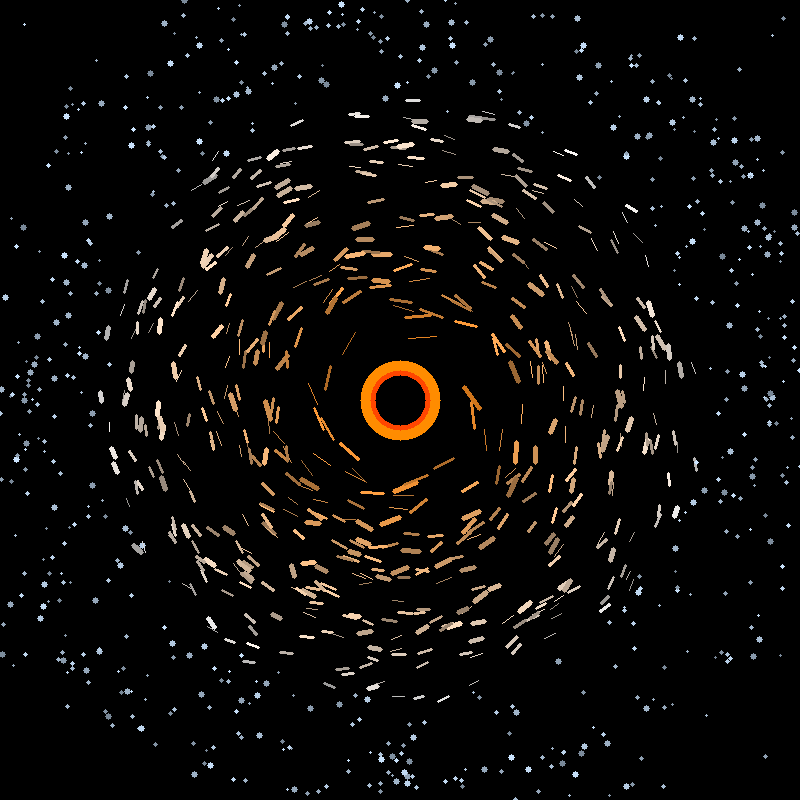

In [ ]:
import cv2
import numpy as np
import random

# --- CONFIGURATION ---
WIDTH, HEIGHT = 800, 800
CENTER = np.array([WIDTH // 2, HEIGHT // 2], dtype=np.float32)
NUM_STARS = 1200
G = 1.5            # Gravitational constant scale
BH_MASS = 150000   # Mass of the black hole
ER_RADIUS = 25     # Event Horizon (Point of no return)
SUCTION_RADIUS = 300 # Distance where stars start getting pulled aggressively

# --- INITIALIZING STARS ---
# Each star has: [pos_x, pos_y, vel_x, vel_y, mass/size, brightness]
stars = np.zeros((NUM_STARS, 6), dtype=np.float32)

def spawn_star(i, initial=False):
    """Spawns a star at a random distance with tangential velocity for orbital rotation."""
    angle = random.uniform(0, 2 * np.pi)
    # If initial setup, scatter them. If respawning, spawn them at the outer edges.
    distance = random.uniform(ER_RADIUS + 10, WIDTH // 1.2) if initial else random.uniform(WIDTH // 2, WIDTH // 1.1)
    
    # Position
    stars[i, 0] = CENTER[0] + np.cos(angle) * distance
    stars[i, 1] = CENTER[1] + np.sin(angle) * distance
    
    # Orbital velocity formula (v = sqrt(G*M/r)) + add a slight inward pull factor
    orbital_speed = np.sqrt((G * BH_MASS) / (distance + 1))
    stars[i, 2] = -np.sin(angle) * orbital_speed * random.uniform(0.8, 1.1) # Orbit X
    stars[i, 3] = np.cos(angle) * orbital_speed * random.uniform(0.8, 1.1)  # Orbit Y
    
    # Slight inward drift to feed the black hole
    stars[i, 2] -= np.cos(angle) * (orbital_speed * 0.15)
    stars[i, 3] -= np.sin(angle) * (orbital_speed * 0.15)
    
    # Size and color traits
    stars[i, 4] = random.choice([1, 2, 2, 3]) # Radius
    stars[i, 5] = random.randint(150, 255)    # Brightness

# Initialize all stars across the screen
for i in range(NUM_STARS):
    spawn_star(i, initial=True)

# --- GOOGLE COLAB SETUP ---
# Detect environment to handle rendering smoothly
try:
    from google.colab.patches import cv2_imshow
    from IPython.display import display, clear_output
    import PIL.Image
    IS_COLAB = True
    output_target = display(display_id=True)
except ImportError:
    IS_COLAB = False

# --- MAIN LOOP ---
frame_count = 0
while True:
    # Create the dark space canvas
    frame = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    
    # 1. Vectorized Physics Calculations
    pos = stars[:, 0:2]
    vel = stars[:, 2:4]
    
    # Calculate distance vectors from each star to the Black Hole
    delta = CENTER - pos
    dist_sq = np.sum(delta**2, axis=1, keepdims=True)
    dist = np.sqrt(dist_sq)
    
    # Prevent division by zero
    dist = np.maximum(dist, 1.0)
    
    # Gravitational acceleration: a = G * M / r^2
    acc_magnitude = (G * BH_MASS) / dist_sq
    acc_vector = (delta / dist) * acc_magnitude
    
    # Update velocities and positions
    vel += acc_vector
    pos += vel
    
    # Write back updated physics data
    stars[:, 0:2] = pos
    stars[:, 2:4] = vel

    # 2. Draw & Manage Stars
    for i in range(NUM_STARS):
        d = dist[i, 0]
        x, y = int(pos[i, 0]), int(pos[i, 1])
        
        # Condition A: Star enters Event Horizon -> Swallowed!
        if d <= ER_RADIUS or x < 0 or x >= WIDTH or y < 0 or y >= HEIGHT:
            spawn_star(i, initial=False)
            continue
            
        # Condition B: Star gets close -> Stretches out (Spaghettification!)
        brightness = int(stars[i, 5])
        size = int(stars[i, 4])
        
        if d < SUCTION_RADIUS:
            # Shift color towards burning orange/red near the horizon
            factor = (SUCTION_RADIUS - d) / (SUCTION_RADIUS - ER_RADIUS)
            color = (int(brightness * (1 - factor)), int(brightness * (1 - factor * 0.5)), brightness)
            
            # Stretch vector to mimic tidal disruption
            tail_x = int(x - vel[i, 0] * 0.4)
            tail_y = int(y - vel[i, 1] * 0.4)
            cv2.line(frame, (x, y), (tail_x, tail_y), color, size)
        else:
            # Distant background stars remain cool blue/white
            color = (brightness, int(brightness * 0.9), int(brightness * 0.8))
            cv2.circle(frame, (x, y), size, color, -1)

    # 3. Draw Singularly Perfect Black Hole
    # Accretion disk inner glow
    cv2.circle(frame, (int(CENTER[0]), int(CENTER[1])), int(ER_RADIUS * 1.6), (0, 140, 255), -1)
    cv2.circle(frame, (int(CENTER[0]), int(CENTER[1])), int(ER_RADIUS * 1.2), (0, 70, 255), -1)
    # The actual singularity (pure darkness)
    cv2.circle(frame, (int(CENTER[0]), int(CENTER[1])), ER_RADIUS, (0, 0, 0), -1)

    # 4. Render output based on platform
    if IS_COLAB:
        frame_count += 1
        if frame_count % 2 == 0:  # Skip frames slightly to smooth out Colab web streams
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            output_target.update(PIL.Image.fromarray(img_rgb))
    else:
        cv2.imshow("Perfect Black Hole Simulator", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

if not IS_COLAB:
    cv2.destroyAllWindows()

In [2]:
import numpy as np
import random
from IPython.display import display, HTML, Javascript
from google.colab.output import eval_js
import json

# HTML + CSS layout with an interactive HTML5 Canvas
html_code = """
<div style="text-align: center; background-color: #0b0b0d; padding: 20px; border-radius: 10px; font-family: monospace;">
    <h2 style="color: #00ecff; margin-bottom: 5px;">Interactive Black Hole Vector Launcher</h2>
    <p style="color: #8a99ad; margin-top: 0;">Click + Drag anywhere to aim and fling a star!</p>
    <canvas id="bhCanvas" width="800" height="800" style="border: 2px solid #1a1c23; border-radius: 5px; cursor: crosshair;"></canvas>
</div>

<script>
const canvas = document.getElementById('bhCanvas');
const ctx = canvas.getContext('2d');

const WIDTH = canvas.width;
const HEIGHT = canvas.height;
const CENTER = { x: WIDTH / 2, y: HEIGHT / 2 };

// Simulator Configuration
const G = 1.5;
const BH_MASS = 150000;
const ER_RADIUS = 25;
const SUCTION_RADIUS = 300;

let stars = [];
let isDragging = false;
let dragStart = { x: 0, y: 0 };
let mousePos = { x: 0, y: 0 };

// Pre-populate background ambient stars
for (let i = 0; i < 400; i++) {
    spawnAmbientStar();
}

function spawnAmbientStar() {
    let angle = Math.random() * 2 * Math.PI;
    let distance = Math.random() * (WIDTH / 1.5 - ER_RADIUS - 10) + ER_RADIUS + 10;
    
    let x = CENTER.x + Math.cos(angle) * distance;
    let y = CENTER.y + Math.sin(angle) * distance;
    
    let orbital_speed = Math.sqrt((G * BH_MASS) / (distance + 1));
    let vx = -Math.sin(angle) * orbital_speed * (0.8 + Math.random() * 0.3);
    let vy = Math.cos(angle) * orbital_speed * (0.8 + Math.random() * 0.3);
    
    // Add inward drift
    vx -= Math.cos(angle) * (orbital_speed * 0.15);
    vy -= Math.sin(angle) * (orbital_speed * 0.15);

    stars.push({
        x: x, y: y,
        vx: vx, vy: vy,
        size: Math.random() * 2 + 1,
        brightness: Math.floor(Math.random() * 105) + 150,
        isCustom: false
    });
}

// Mouse event tracking
canvas.addEventListener('mousedown', (e) => {
    const rect = canvas.getBoundingClientRect();
    dragStart.x = e.clientX - rect.left;
    dragStart.y = e.clientY - rect.top;
    mousePos.x = dragStart.x;
    mousePos.y = dragStart.y;
    isDragging = true;
});

canvas.addEventListener('mousemove', (e) => {
    if (!isDragging) return;
    const rect = canvas.getBoundingClientRect();
    mousePos.x = e.clientX - rect.left;
    mousePos.y = e.clientY - rect.top;
});

canvas.addEventListener('mouseup', (e) => {
    if (!isDragging) return;
    isDragging = false;
    
    // Fling velocity calculation based on vector length
    let vx = (dragStart.x - mousePos.x) * 0.15;
    let vy = (dragStart.y - mousePos.y) * 0.15;
    
    // Launch a custom bright pink high-energy star
    stars.push({
        x: dragStart.x,
        y: dragStart.y,
        vx: vx,
        vy: vy,
        size: 5,
        brightness: 255,
        isCustom: true
    });
});

function updatePhysics() {
    for (let i = stars.length - 1; i >= 0; i--) {
        let s = stars[i];
        
        let dx = CENTER.x - s.x;
        let dy = CENTER.y - s.y;
        let distSq = dx * dx + dy * dy;
        let dist = Math.sqrt(distSq);
        
        if (dist < 1.0) dist = 1.0;
        
        // Newtonian Gravity vector calculation
        let accMag = (G * BH_MASS) / distSq;
        let ax = (dx / dist) * accMag;
        let ay = (dy / dist) * accMag;
        
        s.vx += ax;
        s.vy += ay;
        s.x += s.vx;
        s.y += s.vy;
        
        // If it falls past the Event Horizon or spins out of frame, remove or replace it
        if (dist <= ER_RADIUS || s.x < 0 || s.x >= WIDTH || s.y < 0 || s.y >= HEIGHT) {
            stars.splice(i, 1);
            if (!s.isCustom) spawnAmbientStar(); // Keep background population constant
        }
    }
}

function drawFrame() {
    // Clear canvas with slight transparency for motion trails
    ctx.fillStyle = 'rgba(11, 11, 13, 0.3)';
    ctx.fillRect(0, 0, WIDTH, HEIGHT);
    
    // Render stars
    stars.forEach(s => {
        let dx = CENTER.x - s.x;
        let dy = CENTER.y - s.y;
        let dist = Math.sqrt(dx * dx + dy * dy);
        
        let color;
        if (s.isCustom) {
            // High energy user star path remains distinct neon magenta/pink
            color = `rgb(255, 0, 180)`;
        } else if (dist < SUCTION_RADIUS) {
            // Spaghettification color shift (orange/red heat)
            let factor = (SUCTION_RADIUS - dist) / (SUCTION_RADIUS - ER_RADIUS);
            let r = s.brightness;
            let g = Math.floor(s.brightness * (1 - factor * 0.5));
            let b = Math.floor(s.brightness * (1 - factor));
            color = `rgb(${r}, ${g}, ${b})`;
        } else {
            // Background cold stars
            color = `rgb(${s.brightness}, ${Math.floor(s.brightness * 0.9)}, ${Math.floor(s.brightness * 0.8)})`;
        }
        
        ctx.beginPath();
        if (dist < SUCTION_RADIUS) {
            // Tidal stretching - Draw trail lines mapping vector speed
            ctx.moveTo(s.x, s.y);
            ctx.lineTo(s.x - s.vx * 0.5, s.y - s.vy * 0.5);
            ctx.strokeStyle = color;
            ctx.lineWidth = s.size;
            ctx.stroke();
        } else {
            // Regular circular stars
            ctx.arc(s.x, s.y, s.size, 0, 2 * Math.PI);
            ctx.fillStyle = color;
            ctx.fill();
        }
    });
    
    // Draw Singularly Perfect Black Hole
    // Outer Accretion glow
    ctx.beginPath();
    ctx.arc(CENTER.x, CENTER.y, ER_RADIUS * 1.6, 0, 2 * Math.PI);
    ctx.fillStyle = 'rgba(255, 140, 0, 0.4)';
    ctx.fill();
    
    // Inner Accretion boundary
    ctx.beginPath();
    ctx.arc(CENTER.x, CENTER.y, ER_RADIUS * 1.2, 0, 2 * Math.PI);
    ctx.fillStyle = 'rgba(255, 70, 0, 0.8)';
    ctx.fill();
    
    // Singularity Point of no return
    ctx.beginPath();
    ctx.arc(CENTER.x, CENTER.y, ER_RADIUS, 0, 2 * Math.PI);
    ctx.fillStyle = '#000000';
    ctx.fill();
    
    // Draw the active sling vector line when dragging
    if (isDragging) {
        ctx.beginPath();
        ctx.moveTo(dragStart.x, dragStart.y);
        ctx.lineTo(mousePos.x, mousePos.y);
        ctx.strokeStyle = '#00ecff';
        ctx.lineWidth = 2;
        ctx.setLineDash([4, 4]);
        ctx.stroke();
        ctx.setLineDash([]); // Reset
        
        // Origin target dot
        ctx.beginPath();
        ctx.arc(dragStart.x, dragStart.y, 4, 0, 2 * Math.PI);
        ctx.fillStyle = '#00ecff';
        ctx.fill();
    }
}

function loop() {
    updatePhysics();
    drawFrame();
    requestAnimationFrame(loop);
}

loop();
</script>
"""

display(HTML(html_code))
